# Cloud-Chamber Particle-Track Detection with YOLO11

An end-to-end object-detection pipeline that identifies particle tracks in cloud-chamber
footage using **YOLO11n**. This is an alternative to the Skeletonisation + RandomForest
approach.

**Classes detected**

| id | class | meaning |
|----|-------|---------|
| 0 | `Alpha` | thick, short alpha-particle tracks |
| 1 | `Proton` | proton recoil tracks |
| 2 | `Electron_Positron_Muon` | e⁻ / e⁺ / muon tracks |
| 3 | `Low_Energy_Electron` | low-energy electron squiggles |
| 4 | `Knock_On_Electron` | knock-on (delta) electrons |

**Pipeline**
1. Convert the red-box annotated images in `../Images` into a YOLO dataset (the red boxes
   are *inpainted away* so the model learns the track, not the annotation).
2. Train YOLO11n on the train/val split.
3. Inspect training metrics.
4. Run inference on a single image and on a video.

> **Environment:** run this notebook with the `rocm_env` conda interpreter
> (`C:\Users\PC\anaconda3\envs\rocm_env\python.exe`). On this machine the AMD ROCm GPU
> hits a MIOpen kernel-compile bug during training, so training is done on **CPU**
> (`device="cpu"`). Inference works on either.


## 1. Setup

Import the project modules and check the environment (Torch / Ultralytics / GPU).
All the logic lives in the sibling `.py` files so the notebook stays thin:

- `config.py` — classes, colours, paths, hyper-parameters
- `preprocessing.py` — fast denoising, DoG high-pass filtering, and Otsu binarisation
- `prepare_dataset.py` — red-box → YOLO-label conversion + inpainting
- `train.py` — training wrapper (with automatic CPU fallback)
- `inference.py` — image / video detection helpers


In [1]:
import os
import sys

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

# Make sibling YOLO modules importable regardless of the notebook kernel's cwd.
_candidate_yolo_dirs = [
    os.getcwd(),
    os.path.join(os.getcwd(), "Jun", "YOLO"),
    os.path.join(os.getcwd(), "..", "YOLO"),
    r"C:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO",
]
YOLO_DIR = next(
    (os.path.abspath(path) for path in _candidate_yolo_dirs
     if os.path.isfile(os.path.join(path, "config.py"))),
    None,
)
if YOLO_DIR is None:
    raise FileNotFoundError(
        "Could not locate YOLO/config.py. Open this notebook from the Jun/YOLO project."
    )
if YOLO_DIR not in sys.path:
    sys.path.insert(0, YOLO_DIR)
os.chdir(YOLO_DIR)

import config
import preprocessing
import prepare_dataset
import retrain_from_video_annotations
import inference

%matplotlib inline

# Set True only when a new YOLO training run is required.
RUN_TRAINING = False

print(f"Torch            : {torch.__version__}")
print(f"Python           : {sys.executable}")
print(f"YOLO directory   : {YOLO_DIR}")
print(f"CUDA/ROCm avail  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device       : {torch.cuda.get_device_name(0)}")
print(f"Classes ({config.NUM_CLASSES}): {config.CLASS_NAMES}")
print(f"Images dir       : {os.path.abspath(config.IMAGES_DIR)}")
print(f"Dataset dir      : {config.VIDEO_DATASET_DIR}")
print(f"Preprocessing    : fast denoising + DoG high-pass + Otsu binarisation")
print(f"Chamber size     : {config.CHAMBER_HEIGHT_MM} mm high x {config.CHAMBER_WIDTH_MM} mm wide")
print(f"Chamber ROI      : x={config.CHAMBER_ROI_X}, y={config.CHAMBER_ROI_Y}")
print(f"Retraining       : {'enabled' if RUN_TRAINING else 'skipped'}")


WARNING Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\PC\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch            : 2.9.1+rocm7.2.1
Python           : c:\Users\PC\anaconda3\envs\rocm_env\python.exe
YOLO directory   : c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO
CUDA/ROCm avail  : True
GPU device       : AMD Radeon RX 9060 XT
Classes (5): ['Alpha', 'Proton', 'Electron_Positron_Muon', 'Low_Energy_Electron', 'Knock_On_Electron']
Images dir       : c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\Images
Dataset dir      : c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\dataset\video_annotations_dataset
Preprocessing    : fast denoising + DoG high-pass + Otsu 

## 2. Build the YOLO dataset

`retrain_from_video_annotations.prepare_video_dataset()` reads the video and its CVAT XML,
accepts both bounding boxes and polylines, converts polylines to YOLO bounding boxes, and
applies the shared preprocessing pipeline before saving every training image:

1. Fast non-local-means denoising
2. Difference of Gaussians high-pass filtering
3. Otsu binarisation

The resulting dataset is written to `dataset/video_annotations_dataset/` and is selected
automatically by `train.py`.

> Re-running this cell rebuilds the video-derived dataset from scratch.


In [2]:
import retrain_from_video_annotations

video_dataset_dir = retrain_from_video_annotations.prepare_video_dataset(
    video_path=config.VIDEO_SOURCE,
    xml_path=config.VIDEO_ANNOTATIONS_XML,
    dataset_dir=config.VIDEO_DATASET_DIR,
)
print(f"Video-derived dataset ready: {video_dataset_dir}")


VIDEO-BASED YOLO DATASET READY
Video: c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\Videos\VID_20221231_002624.mp4
Annotations: c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\Videos\annotations.xml
Frames written: 135
Class counts:
  0: Alpha -> 9
  1: Proton -> 17
  2: Electron_Positron_Muon -> 106
  3: Low_Energy_Electron -> 47
  4: Knock_On_Electron -> 12
Dataset dir: c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\dataset\video_annotations_dataset
data.yaml: c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\dataset\video_annotations_dataset\data.yaml
Video-derived dataset ready: c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\dataset\video_annotations_dataset


## 3. Sanity-check the labels

Draw the generated YOLO labels back onto a few (inpainted) training images. The boxes
should sit on the tracks and the original **red annotation rectangles should be gone**.


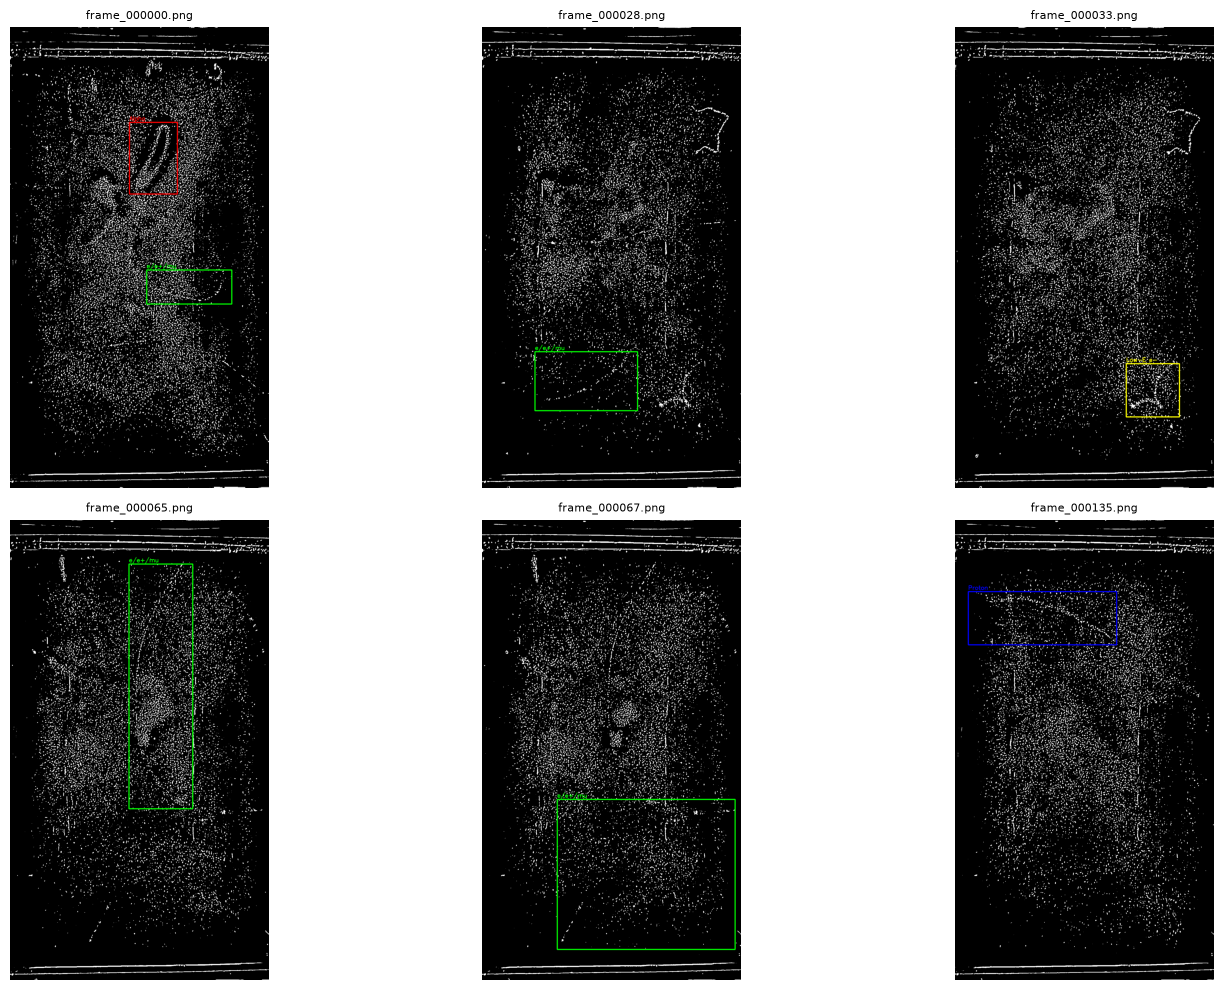

In [3]:
def draw_yolo_labels(img_path, label_path):
    """Draw normalised YOLO labels (cls cx cy w h) onto an image (BGR->RGB)."""
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    if os.path.isfile(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.split()
                if len(parts) != 5:
                    continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = (float(v) for v in parts[1:])
                x1 = int((cx - bw / 2) * w)
                y1 = int((cy - bh / 2) * h)
                x2 = int((cx + bw / 2) * w)
                y2 = int((cy + bh / 2) * h)
                color = config.CLASS_COLORS.get(cls_id, (255, 255, 255))
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
                cv2.putText(img, config.DISPLAY_NAMES.get(cls_id, str(cls_id)),
                            (x1, max(0, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX,
                            0.8, color, 2)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


train_img_dir = os.path.join(config.VIDEO_DATASET_DIR, "images", "train")
train_lbl_dir = os.path.join(config.VIDEO_DATASET_DIR, "labels", "train")
samples = sorted(os.listdir(train_img_dir))[:6]

cols = 3
rows = (len(samples) + cols - 1) // cols
plt.figure(figsize=(16, 5 * rows))
for i, name in enumerate(samples):
    img_path = os.path.join(train_img_dir, name)
    lbl_path = os.path.join(train_lbl_dir, os.path.splitext(name)[0] + ".txt")
    plt.subplot(rows, cols, i + 1)
    plt.imshow(draw_yolo_labels(img_path, lbl_path))
    plt.title(name, fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 4. Train YOLO11n

Set `RUN_TRAINING = True` in the setup cell to train a new model. The default is
`False`, so the training cell is skipped and later inference uses the existing
checkpoint from `config.BEST_WEIGHTS` when available.

Training writes to `runs/cloud_chamber/yolo11n_tracks/` and copies the best checkpoint to
`config.BEST_WEIGHTS`.

> **Slow on CPU.** 300 epochs at 960 px takes a while on CPU. For a quick smoke-test lower
> the settings, e.g. `train.train(device="cpu", epochs=60, imgsz=640)`.

> This can also be launched from a terminal:
> ```powershell
> & "C:\Users\PC\anaconda3\envs\rocm_env\python.exe" train.py --device cpu
> ```


In [4]:
import train

if RUN_TRAINING:
    # Force CPU on this machine (ROCm/MIOpen GPU training is broken for gfx1200).
    # Uses config defaults for epochs/imgsz/batch. Tune here for a quick run.
    results = train.train(device="cpu")
else:
    results = None
    print("Skipping YOLO retraining; using the existing checkpoint for inference.")


Skipping YOLO retraining; using the existing checkpoint for inference.


## 5. Training results

Ultralytics saves loss/metric curves, a confusion matrix, and labelled validation batches
into the run directory. Display the key ones below.


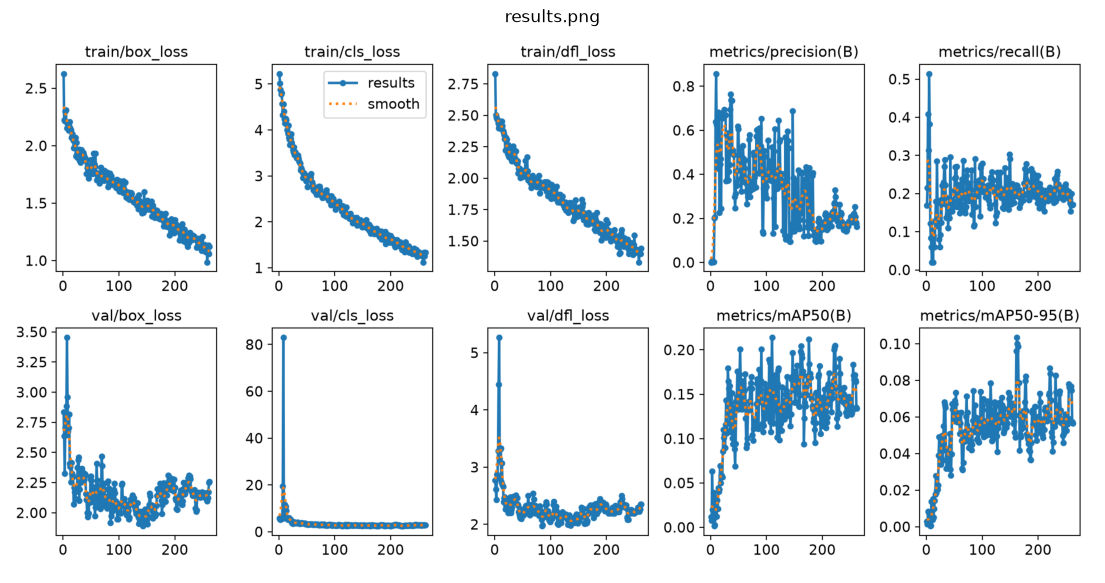

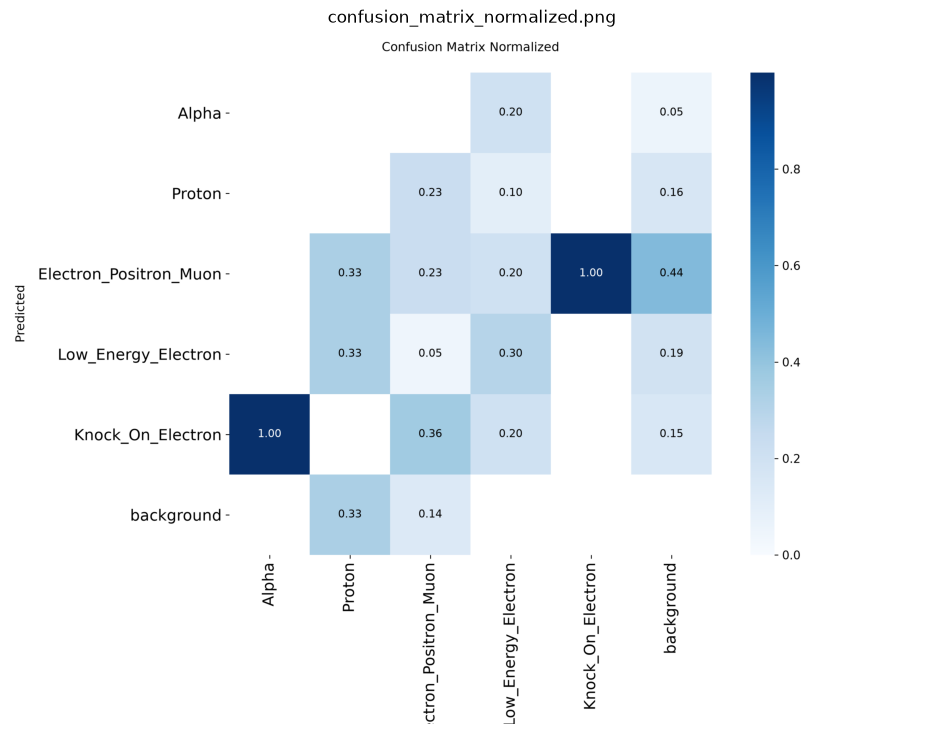

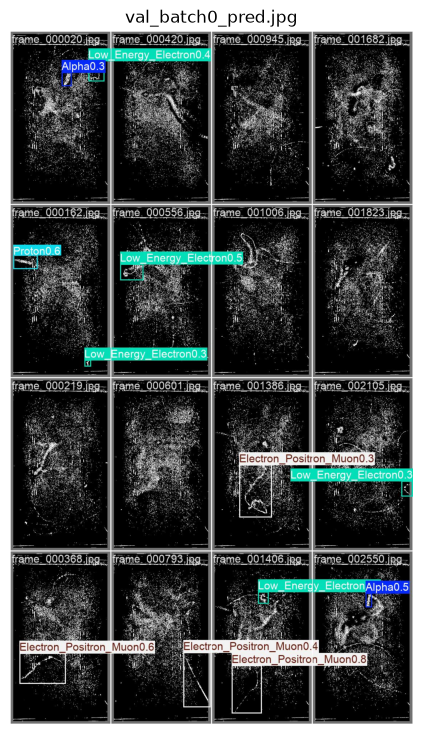

In [5]:
run_dir = os.path.join(config.RUNS_DIR, config.PROJECT_NAME, config.RUN_NAME)

for plot_name in ["results.png", "confusion_matrix_normalized.png", "val_batch0_pred.jpg"]:
    p = os.path.join(run_dir, plot_name)
    if os.path.isfile(p):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(14, 9))
        plt.imshow(img)
        plt.title(plot_name)
        plt.axis("off")
        plt.show()
    else:
        print(f"(not found yet: {plot_name} — run training first)")


## 6. Inference on a single image

Load the trained weights (falls back to the base model if training hasn't produced
`best.pt` yet) and run detection on one image.


Image: frame_000020.png
Detections inside chamber: 1
  Low_Energy_Electron      conf=0.79 length~19.8 mm bbox=(873, 309, 1051, 538)


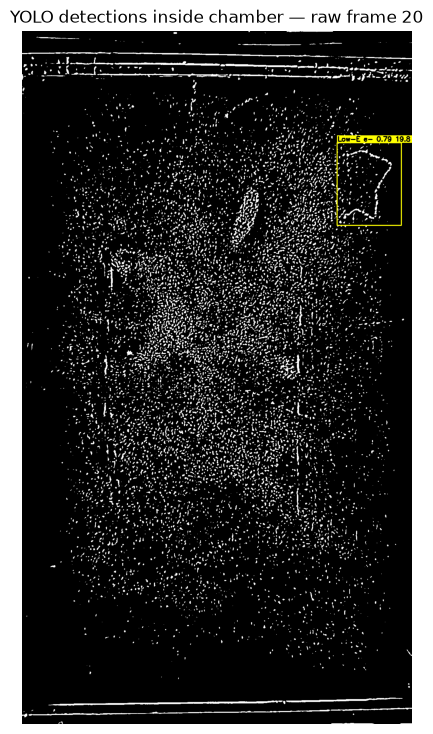

In [6]:
model = inference.load_model()  # uses config.BEST_WEIGHTS, or base model if missing

# Use the raw video frame for inference. Validation PNGs are already preprocessed
# for training, so passing one here would apply preprocessing twice.
val_img_dir = os.path.join(config.VIDEO_DATASET_DIR, "images", "val")
val_images = sorted(os.listdir(val_img_dir))
val_image_name = val_images[0]
frame_index = int(os.path.splitext(val_image_name)[0].rsplit("_", 1)[-1])

video_capture = cv2.VideoCapture(config.VIDEO_SOURCE)
video_capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
raw_ok, raw_frame = video_capture.read()
video_capture.release()
if not raw_ok:
    raise RuntimeError(f"Could not read raw video frame {frame_index}")

test_img_path = os.path.join(config.IMAGE_OUTPUT_DIR, f"frame_{frame_index:06d}_raw_input.png")
os.makedirs(config.IMAGE_OUTPUT_DIR, exist_ok=True)
cv2.imwrite(test_img_path, raw_frame)

annotated, detections = inference.detect_image(model, test_img_path)

print(f"Image: {val_image_name}")
print(f"Detections inside chamber: {len(detections)}")
for d in detections:
    print(
        f"  {d['class_name']:24s} conf={d['confidence']:.2f} "
        f"length~{d['length_mm']:.1f} mm bbox={d['bbox']}"
    )

plt.figure(figsize=(14, 9))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"YOLO detections inside chamber — raw frame {frame_index}")
plt.axis("off")
plt.show()


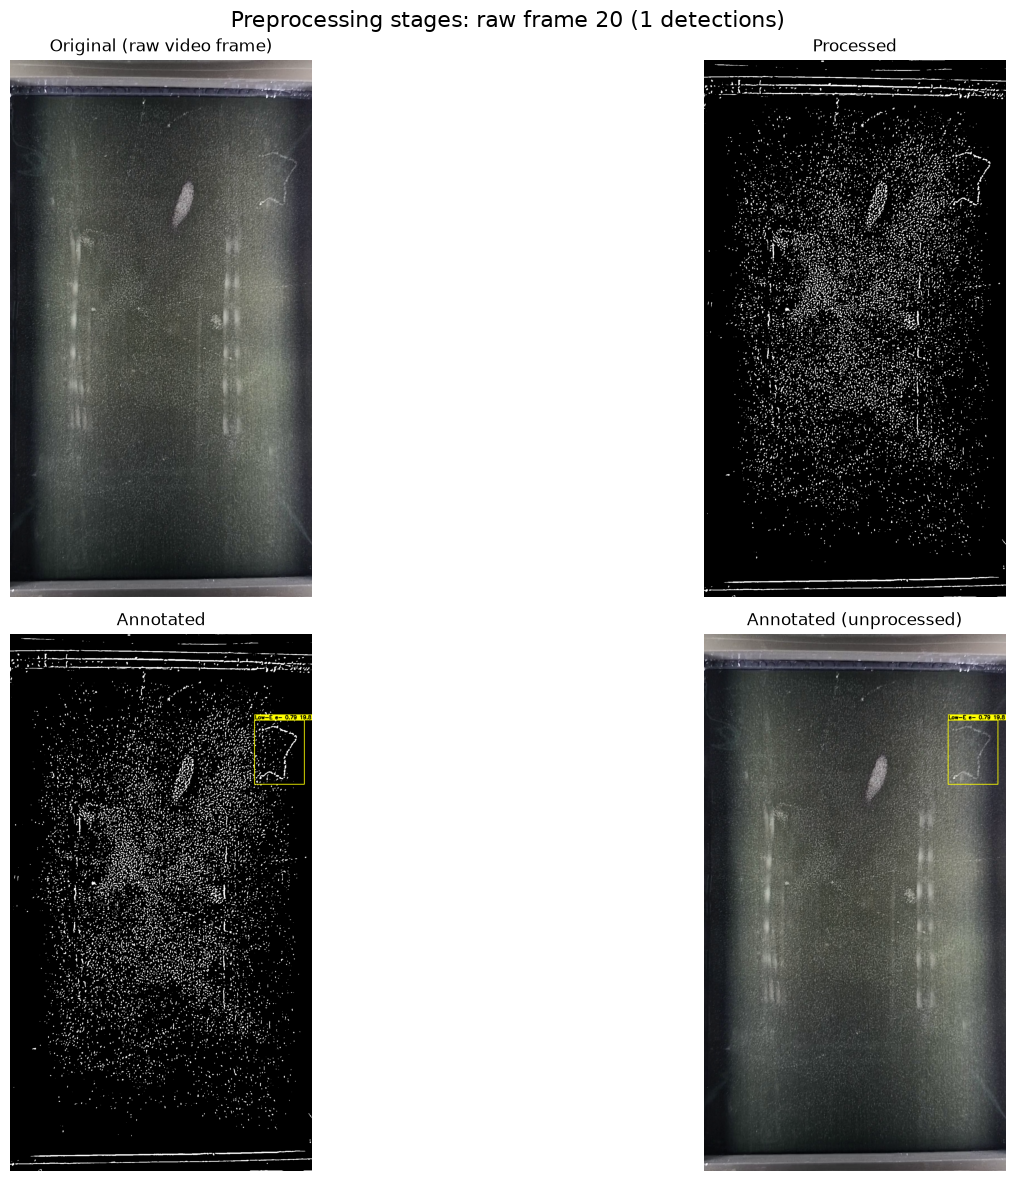

Saved stages to: c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\output_images


In [7]:
import matplotlib.pyplot as plt

# Validation images are already preprocessed for training. Recover the matching
# raw video frame so the Original panel is genuinely unprocessed.
frame_stem = os.path.splitext(val_images[0])[0]
frame_index = int(frame_stem.rsplit("_", 1)[-1])
video_capture = cv2.VideoCapture(config.VIDEO_SOURCE)
video_capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
raw_ok, raw_frame = video_capture.read()
video_capture.release()
if not raw_ok:
    raise RuntimeError(f"Could not read raw video frame {frame_index}")

raw_input_path = os.path.join(config.IMAGE_OUTPUT_DIR, f"{frame_stem}_raw_input.png")
os.makedirs(config.IMAGE_OUTPUT_DIR, exist_ok=True)
cv2.imwrite(raw_input_path, raw_frame)

stage_result = inference.process_image(
    model,
    raw_input_path,
    output_path=os.path.join(config.IMAGE_OUTPUT_DIR, "stage_preview.png"),
    display=False,
)

stage_paths = [
    ("Original (raw video frame)", stage_result["original_path"]),
    ("Processed", stage_result["processed_path"]),
    ("Annotated", stage_result["annotated_path"]),
    ("Annotated (unprocessed)", stage_result["annotated_unprocessed_path"]),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for axis, (title, image_path) in zip(axes.flat, stage_paths):
    image = cv2.imread(image_path)
    if image is None:
        axis.set_title(f"{title} (unavailable)")
        axis.axis("off")
        continue
    axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis("off")

fig.suptitle(
    f"Preprocessing stages: raw frame {frame_index} "
    f"({stage_result['count']} detections)",
    fontsize=16,
)
plt.tight_layout()
plt.show()

print(f"Saved stages to: {stage_result['output_dir']}")


## 7. Inference on video

Run the detector frame-by-frame over a cloud-chamber video and write an annotated MP4 to
`config.VIDEO_OUTPUT`.

> On CPU this is slow for a full clip. Use `max_frames` to preview a short segment first.
> Set `VIDEO_INPUT` in `config.py` (or pass `input_path=...`) to point at your clip.


In [8]:
# Preview the first 30 frames (set max_frames=None for the whole video).
video_stats = inference.process_video(
    model,
    input_path=config.VIDEO_INPUT,
    output_path=config.VIDEO_OUTPUT,
    max_frames=30,
)
video_stats


Video: c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\Videos\VID_20221231_002624.mp4
  Resolution: 1080x1920  FPS: 29.7  Frames: 4299

PROCESSING COMPLETE
Output saved to: c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\output_yolo.mp4
Frames processed: 30
Total detections: 96

Detections per class:
  Alpha: 4
  Proton: 18
  Electron_Positron_Muon: 31
  Low_Energy_Electron: 43
  Knock_On_Electron: 0


{'frames': 30,
 'total_detections': 96,
 'class_counts': {0: 4, 1: 18, 2: 31, 3: 43, 4: 0},
 'output_path': 'c:\\Users\\PC\\Desktop\\RSW Coursework\\Y3S1\\Image Processing\\Jun\\YOLO\\output_yolo.mp4'}

## 8. Improving recall and physical consistency

Whole-frame, high-confidence inference misses most of the faint tracks in the video.
The pipeline now includes:

- **Shared preprocessing** (`preprocessing.py`) — fast non-local-means denoising, a
  Difference of Gaussians high-pass filter, and Otsu binarisation are applied identically
  to training images and inference frames.
- **Calibrated chamber filtering** — detections are limited to the configured 125 mm x 80 mm
  chamber region.
- **Rough physical track length** — each detection reports the diagonal length of its pixel
  bounding box converted to millimetres using the chamber dimensions.
- **Low confidence threshold** (`CONF_THRESHOLD = 0.10`) — favours recall.
- **Test-time augmentation** (`USE_TTA`) — multi-scale + flipped inference.
- **Tiled / SAHI-style inference** (`USE_TILING`) — slices each high-res frame into
  overlapping tiles, detects per tile, and merges with class-wise NMS.

The cell below compares whole-frame vs enhanced+tiled detection on one image.


Whole-frame @0.25   : 1 detections
Enhanced+tiled+TTA  : 1 detections


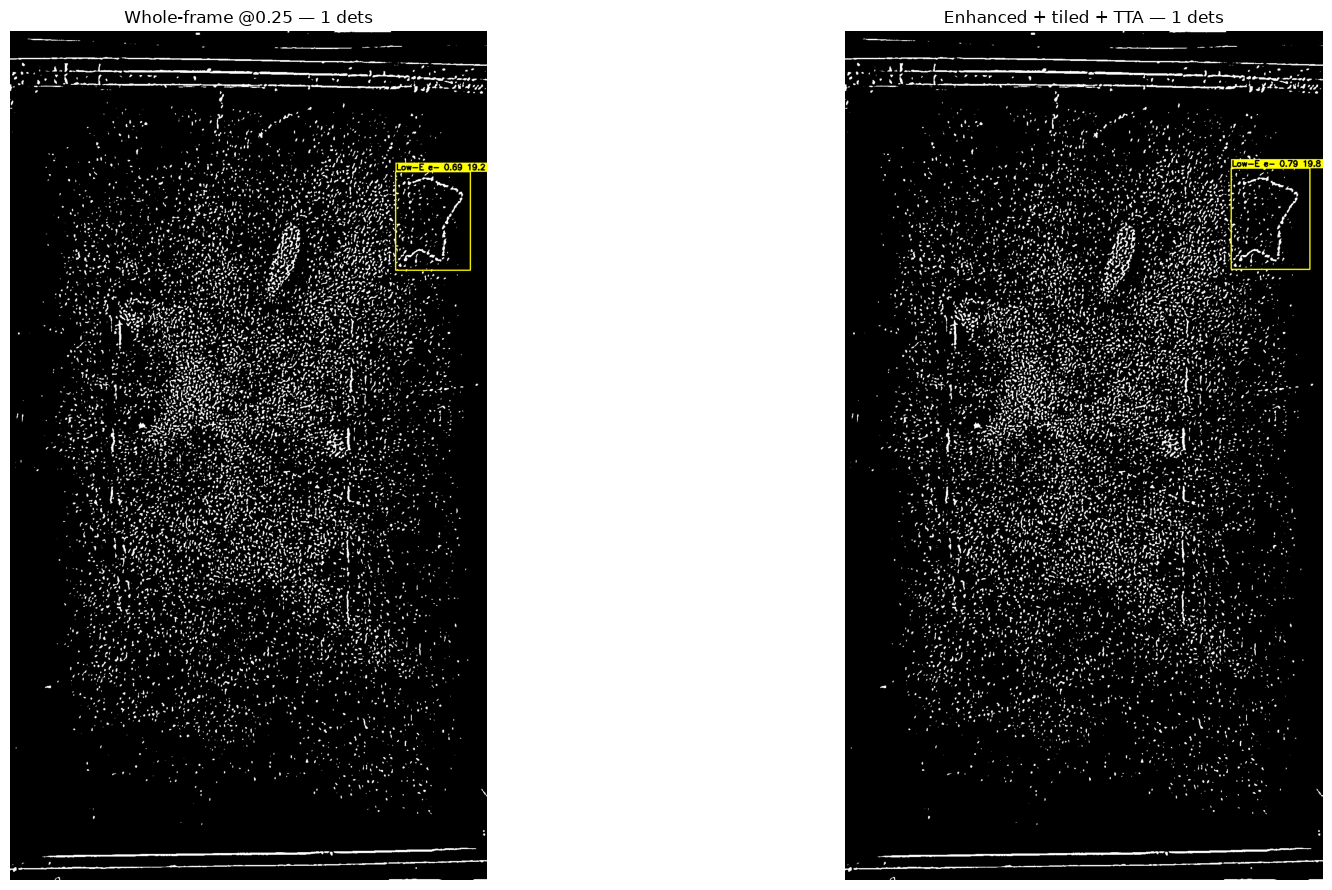

In [9]:
import importlib
import preprocessing
importlib.reload(config)
importlib.reload(preprocessing)
importlib.reload(inference)

# Compare plain whole-frame detection vs enhanced + tiled + TTA on one val image.
plain_annot, plain_dets = inference.detect_image(
    model, test_img_path, conf=0.25, use_tiling=False, use_tta=False,
)
boosted_annot, boosted_dets = inference.detect_image(
    model, test_img_path, use_tiling=True, use_tta=True,
)

print(f"Whole-frame @0.25   : {len(plain_dets)} detections")
print(f"Enhanced+tiled+TTA  : {len(boosted_dets)} detections")

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
axes[0].imshow(cv2.cvtColor(plain_annot, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Whole-frame @0.25 — {len(plain_dets)} dets")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(boosted_annot, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Enhanced + tiled + TTA — {len(boosted_dets)} dets")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 9. Expand the dataset (the real fix)

Sample more frames from the source videos so you can label them densely. Annotate
**every** visible track in each extracted frame (LabelImg / Roboflow / CVAT → YOLO txt),
then rebuild the dataset and retrain. Frames use the same denoising, DoG high-pass,
and Otsu binarisation preprocessing as inference.


In [10]:
import extract_frames

# Sample one frame every 30 frames from every video in ../Videos.
# Tune `every` lower for more frames. Output goes to YOLO/extracted_frames/.
n_saved = extract_frames.extract_all(every=30)
print(f"\nExtracted {n_saved} frames for annotation -> {extract_frames.FRAMES_OUT_DIR}")


Video: VID_20221231_002624.mp4  frames=4299  every=30
  saved 144 frames -> c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\extracted_frames

Done. 144 frames written to c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\extracted_frames
Next: label EVERY visible track in each frame, then rebuild the dataset.

Extracted 144 frames for annotation -> c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\extracted_frames
